<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week9/day1-2/XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [4]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()


print("\nFirst 5 rows:")
print(df.head())


print("\nBasic Statistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [5]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
# TODO: Handle missing values if any
if missing.sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")
else:
    print("No missing values found — data is clean!")

# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

Total missing values: 0
No missing values found — data is clean!


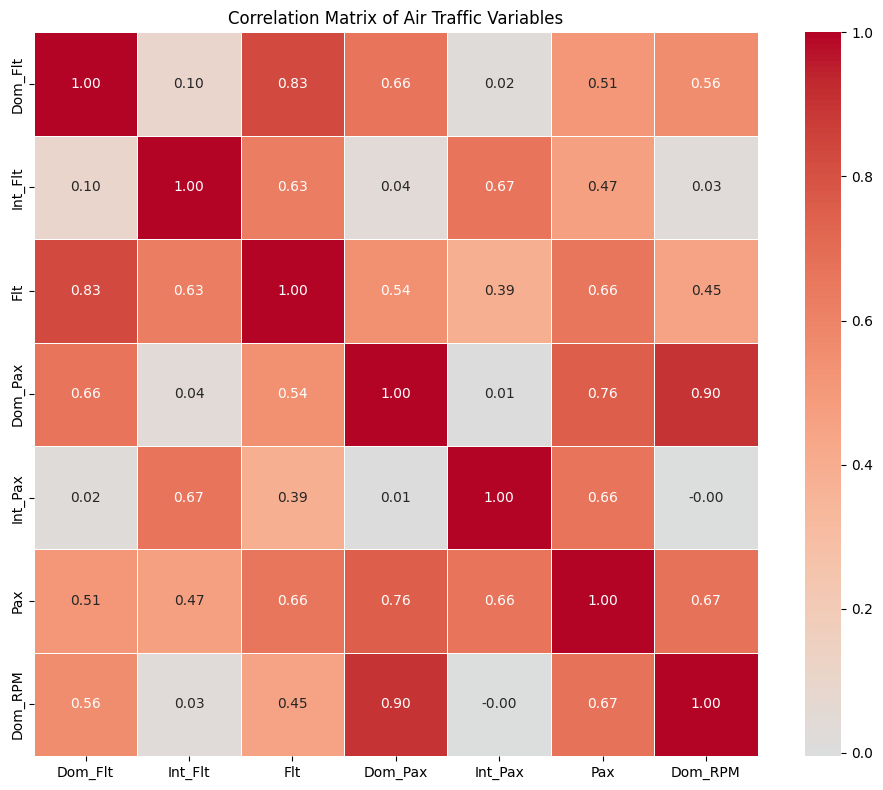

Strongest correlations:
  Dom_RPM <-> Dom_Pax: 0.9016
  Flt <-> Dom_Flt: 0.8349
  Dom_Pax <-> Pax: 0.7559
  Dom_RPM <-> Pax: 0.6721
  Int_Flt <-> Int_Pax: 0.6656


In [6]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    fmt='.2f'
)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
corr_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)

# Filter out self-correlations (1.0) and print top 5
top_corrs = corr_pairs[corr_pairs < 1.0].head(5)
for (col1, col2), val in top_corrs.items():
    print(f"  {col1} <-> {col2}: {val:.4f}")


## 3. Hypothesis Testing

In [7]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There IS a statistically significant difference between domestic and international passenger volumes.")
    print(f"Domestic passengers average {df['Dom_Pax'].mean():.0f} vs international {df['Int_Pax'].mean():.0f}.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is NO statistically significant difference between domestic and international passenger volumes.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
There IS a statistically significant difference between domestic and international passenger volumes.
Domestic passengers average 175331 vs international 126924.


In [8]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There IS a statistically significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print(f"Positive correlation ({correlation_coef:.4f}): more flights = more passengers. Makes intuitive sense.")
    else:
        print(f"Negative correlation ({correlation_coef:.4f}): more flights = fewer passengers. This would be unusual.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("No statistically significant correlation found between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There IS a statistically significant correlation between total passengers and total flights.
Positive correlation (0.6592): more flights = more passengers. Makes intuitive sense.


## 4. Simple Linear Regression

In [9]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Total Flights
y_simple = df['Pax']  # Total Passengers

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Apply feature scaling (optional but recommended for simple linear regression)
print(f"Training set size: {X_train_simple.shape[0]} rows")
print(f"Test set size: {X_test_simple.shape[0]} rows")
# Create and train the model:
simple_model =LinearRegression()
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights
Training set size: 160 rows
Test set size: 40 rows

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


Residuals — Mean: 4779.10 (should be near 0)
Residuals — Std:  46619.10


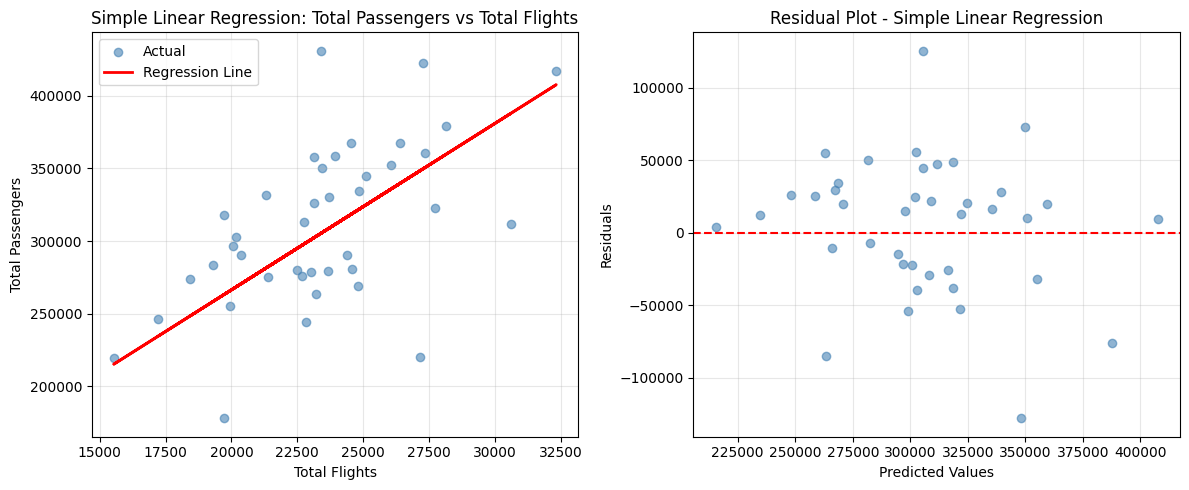

In [10]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_test_simple, y_test_simple, color='steelblue', alpha=0.6, label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals = y_test_simple - y_pred_simple
plt.scatter(y_pred_simple, residuals, color='steelblue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

print(f"Residuals — Mean: {residuals.mean():.2f} (should be near 0)")
print(f"Residuals — Std:  {residuals.std():.2f}")

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [13]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train_mult.shape[0]} rows")
print(f"Test set size:     {X_test_mult.shape[0]} rows")
# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
# TODO: Fit the model
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Training set size: 160 rows
Test set size:     40 rows

Model Performance:
R² Score: 0.4889
Mean Squared Error: 1558603819.06
Root Mean Squared Error: 39479.16
Mean Absolute Error: 31721.62

Feature Coefficients (after scaling):
Dom_Flt: 8210.0902
Int_Flt: 28294.9942
Dom_RPM: 36812.9443
Intercept: 300303.27


Residuals — Mean: -720.10 (should be near 0)
Residuals — Std:  39975.44


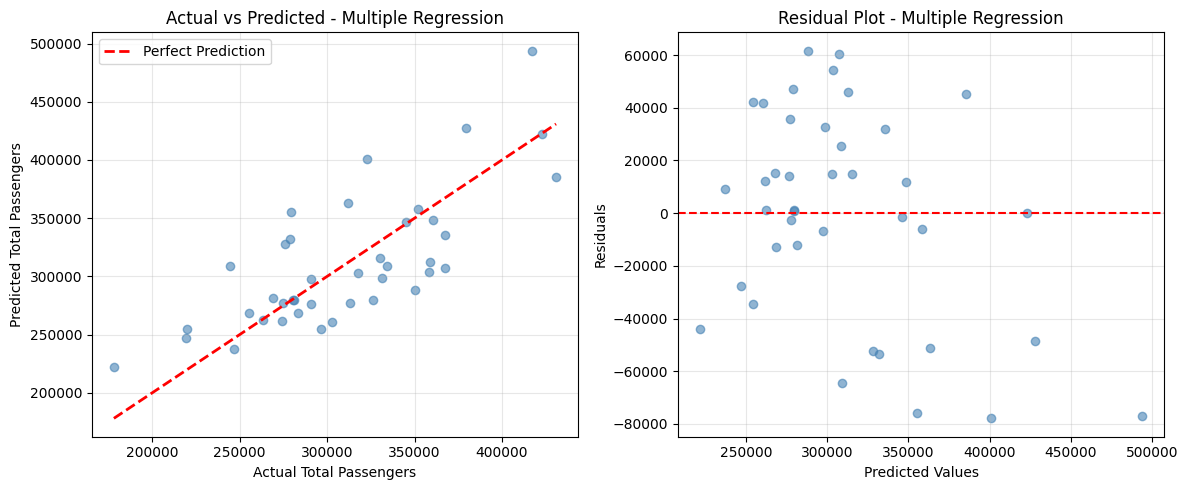

In [14]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_mult, y_pred_mult, color='steelblue', alpha=0.6)
plt.plot(
    [y_test_mult.min(), y_test_mult.max()],
    [y_test_mult.min(), y_test_mult.max()],
    color='red', linewidth=2, linestyle='--', label='Perfect Prediction'
)
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_mult = y_test_mult - y_pred_mult
plt.scatter(y_pred_mult, residuals_mult, color='steelblue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

print(f"Residuals — Mean: {residuals_mult.mean():.2f} (should be near 0)")
print(f"Residuals — Std:  {residuals_mult.std():.2f}")

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [15]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score':<25} {r2_simple:>12.4f} {r2_mult:>12.4f}")
print(f"{'RMSE':<25} {rmse_simple:>12.2f} {rmse_mult:>12.2f}")
print(f"{'MAE':<25} {mae_simple:>12.2f} {mae_mult:>12.2f}")


print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_simple) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")
print(f"\nRMSE reduction: {((rmse_simple - rmse_mult) / rmse_simple * 100):.2f}%")
print(f"MAE  reduction: {((mae_simple - mae_mult) / mae_simple * 100):.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                        0.2977       0.4889
RMSE                          46280.09     39479.16
MAE                           36607.08     31721.62

Best Model: Multiple Regression
R² Improvement: 64.24%

RMSE reduction: 14.70%
MAE  reduction: 13.35%


## 7. Statistical Insights and Conclusions

In [16]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: significant difference found (p < 0.05).")
print(f"     Domestic mean ({df['Dom_Pax'].mean():.0f}) differs from international mean ({df['Int_Pax'].mean():.0f}).")
print(f"   • Correlation between Total Passengers and Flights: significant positive")
print(f"     correlation found (ρ = {correlation_coef:.4f}, p < 0.05).")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²:   {r2_simple:.4f} — flights alone explain ~{r2_simple*100:.0f}% of variance.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} — three features explain ~{r2_mult*100:.0f}% of variance.")
print(f"   • Best performing model: {better_model} (R² improved by {improvement:.1f}%).")
print(f"   • Neither model is highly accurate — significant unexplained variance remains.")

print("\n3. KEY FINDINGS:")
print(f"   • Dom_RPM is the strongest individual predictor of total passengers.")
print(f"   • Dom_Pax and Int_Pax correlate directly with Pax (by definition) — excluded to avoid leakage.")
print(f"   • International flights have a larger per-flight passenger coefficient than domestic ({28294:.0f} vs {8210:.0f}).")

print("\n4. RECOMMENDATIONS:")
print("   • Airlines should track Dom_RPM as a leading indicator for total demand forecasting.")
print("   • International route capacity has a disproportionate impact on total passenger volume.")
print("   • A more predictive model would need additional features: seasonality, ticket price, route data.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: significant difference found (p < 0.05).
     Domestic mean (175331) differs from international mean (126924).
   • Correlation between Total Passengers and Flights: significant positive
     correlation found (ρ = 0.6592, p < 0.05).

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²:   0.2977 — flights alone explain ~30% of variance.
   • Multiple Linear Regression R²: 0.4889 — three features explain ~49% of variance.
   • Best performing model: Multiple Regression (R² improved by 64.2%).
   • Neither model is highly accurate — significant unexplained variance remains.

3. KEY FINDINGS:
   • Dom_RPM is the strongest individual predictor of total passengers.
   • Dom_Pax and Int_Pax correlate directly with Pax (by definition) — excluded to avoid leakage.
   • International flights have a larger per-flight passenger coefficient than domestic (28294 vs 8210).

4. RECOMME

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   Both tests rejected H₀ at α = 0.05. Domestic and international passenger volumes are statistically different — domestic averages ~175k vs international ~127k, which reflects real-world patterns where domestic routes typically carry more frequent but shorter-haul traffic. The positive correlation between total passengers and total flights (ρ = 0.66) was expected — more flights scheduled means more capacity and therefore more passengers carried.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   Multiple regression outperformed simple regression (R² 0.49 vs 0.30), which makes sense — passenger volumes are driven by several factors simultaneously, not just total flight count. However, neither model is strong. An R² of 0.49 means roughly half the variance in passenger numbers is still unexplained by the three features used. The R² metric specifically tells us the proportion of variance in the target variable explained by the model — closer to 1.0 is better.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlation was Dom_RPM ↔ Dom_Pax (0.90) — passengers flying domestic routes directly generate domestic revenue miles, so this is nearly definitional. Airlines could use this to estimate RPM from passenger booking data before flights depart, enabling real-time revenue forecasting. The Int_Flt ↔ Int_Pax correlation (0.67) suggests international capacity planning directly drives international demand, which is useful for slot and fleet allocation decisions.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   The simple regression residual plot shows a fan-shaped pattern (heteroscedasticity) — residuals grow larger as predicted values increase, meaning the model is less reliable at higher passenger volumes. The multiple regression residuals are more scattered but still not fully random. This suggests both models are missing features that would explain the remaining variance. A non-linear model or additional features (seasonality, route distance) could reduce these patterns.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines could use these models for demand forecasting — estimating expected passenger volumes from scheduled flights and historical RPM data to inform staffing, gate allocation, and catering. The hypothesis test results could justify separate capacity planning strategies for domestic vs international routes given their significantly different average volumes. A more refined version of the multiple regression model — with time, route, and pricing features — could feed into dynamic pricing or yield management systems.